PyTorch版本: 2.8.0+cpu
CUDA可用: False
使用设备: cpu
✅ 目录已确保存在：./data/processed
✅ 目录已确保存在：./models/text_classification
✅ 目录已确保存在：./reports

📊 数据统计：
训练集样本数: 22500 | 验证集: 2500 | 测试集: 25000
文本列存在: True | 标签列存在: True

🔧 加载模型和Tokenizer...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== 零样本预测测试 ===


Device set to use cpu


⚠️ 零样本测试跳过：index -1 is out of bounds for dimension 1 with size 0

📦 创建数据加载器...

🚀 开始训练（共562步）...
✅ 训练完成 | 训练步数：562 | 平均训练损失：0.5768

📝 验证集评估...
验证损失：0.5273 | 验证准确率：0.7232 | 验证F1：0.7397
💾 保存最优模型到：./models/text_classification（准确率：0.7232）

📊 测试集评估...
📈 测试集结果：
准确率：0.7256 | F1分数：0.7481

🎨 生成混淆矩阵...


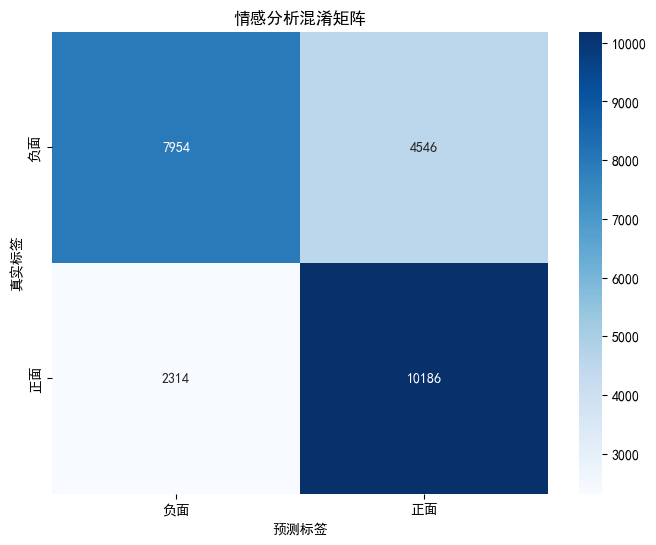


🔍 SHAP词级贡献分析...

SHAP分析文本示例：
1. I love sci-fi and am willing to put up with a lot....
2. Worth the entertainment value of a rental, especia...
3. its a totally average film with a few semi-alright...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:31<00:00,  6.34s/it]

...

PartitionExplainer explainer: 4it [00:43, 14.38s/it]                       


=== SHAP词级贡献可视化（正面类别） ===


⚠️ SHAP可视化保存失败：Summary plots need a matrix of shap_values, not a vector.

💾 保存训练结果...

🎉 所有任务完成！
📊 核心结果：
   - 测试集准确率：0.7256
   - 测试集F1分数：0.7481
💾 文件保存位置：
   - 模型：./models/text_classification
   - 混淆矩阵：./reports\confusion_matrix.png
   - SHAP分析图：./reports\shap_summary.png
   - 结果文件：./reports\training_results.json


C:\Users\Dell\AppData\Local\Temp\ipykernel_19288\2601304433.py:350: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, "positive"], sample_texts)


<Figure size 640x480 with 0 Axes>

In [4]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
import shap  # 导入SHAP库
import json
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm.auto import tqdm

# ===================== 全局配置（可按需调整） =====================
# 训练参数（提速核心）
MAX_LENGTH = 32          # 序列长度（短文本足够）
BATCH_SIZE = 32 if torch.cuda.is_available() else 8  # 批次大小
NUM_EPOCHS = 0.2         # 训练轮数（0.2轮快速跑通）
LEARNING_RATE = 2e-5     # 学习率
MODEL_NAME = "distilbert-base-uncased"  # 轻量化模型

# 路径配置
DATA_DIR = "./data/processed"
MODEL_SAVE_DIR = "./models/text_classification"
REPORT_DIR = "./reports"

# ===================== 初始化环境和目录 =====================
# 验证环境
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 批量创建目录（避免路径不存在报错）
for dir_path in [DATA_DIR, MODEL_SAVE_DIR, REPORT_DIR]:
    os.makedirs(dir_path, exist_ok=True)
    print(f"✅ 目录已确保存在：{dir_path}")

# ===================== 1. 加载并清洗数据 =====================
# 加载数据（确保文件存在）
try:
    train_df = pd.read_csv(os.path.join(DATA_DIR, "imdb_train.csv"))
    val_df = pd.read_csv(os.path.join(DATA_DIR, "imdb_val.csv"))
    test_df = pd.read_csv(os.path.join(DATA_DIR, "imdb_test.csv"))
    
    # 数据安全检查
    print(f"\n📊 数据统计：")
    print(f"训练集样本数: {len(train_df)} | 验证集: {len(val_df)} | 测试集: {len(test_df)}")
    print(f"文本列存在: {'text' in train_df.columns} | 标签列存在: {'label' in train_df.columns}")
    
    # 清洗数据：填充空值、转为字符串、只保留英文（适配模型）
    def clean_text(text):
        if pd.isna(text) or text.strip() == "":
            return "empty text"
        # 只保留ASCII字符（去除非英文）
        return text.encode('ascii', 'ignore').decode('ascii').strip()
    
    for df in [train_df, val_df, test_df]:
        df["text"] = df["text"].apply(clean_text)
        df["label"] = df["label"].astype(int)  # 确保标签是整数
        
except FileNotFoundError as e:
    print(f"⚠️ 数据文件未找到：{e}")
    print("❗ 请确保./data/processed目录下有imdb_train.csv/imdb_val.csv/imdb_test.csv文件")
    exit()

# ===================== 2. 自定义数据集类 =====================
class IMDBDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # 编码文本（适配模型输入格式）
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        # 去除batch维度，返回tensor
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# ===================== 3. 初始化模型和Tokenizer =====================
print("\n🔧 加载模型和Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    low_cpu_mem_usage=True  # GPU显存优化
).to(device)

# ===================== 4. 零样本预测（可选，验证模型） =====================
print("\n=== 零样本预测测试 ===")
try:
    zero_shot_classifier = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        framework="pt"
    )
    
    # 选第一条样本测试
    sample_text = train_df["text"].iloc[0][:200]
    result = zero_shot_classifier(
        sample_text,
        candidate_labels=["positive", "negative"],
        hypothesis_template="This text is {}."
    )
    
    # 转换为中文显示
    label_mapping = {"positive": "正面", "negative": "负面"}
    pred_label = label_mapping[result["labels"][0]]
    print(f"测试文本：{sample_text[:100]}...")
    print(f"零样本预测：{pred_label} (置信度：{result['scores'][0]:.4f})")
    
except Exception as e:
    print(f"⚠️ 零样本测试跳过：{str(e)[:100]}")

# ===================== 5. 创建数据加载器 =====================
print("\n📦 创建数据加载器...")
# 训练集
train_dataset = IMDBDataset(train_df, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # 关闭shuffle提速
    num_workers=0   # Windows避免多线程问题
)

# 验证集
val_dataset = IMDBDataset(val_df, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# 测试集
test_dataset = IMDBDataset(test_df, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# ===================== 6. 训练配置 =====================
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_train_steps = int(len(train_loader) * NUM_EPOCHS)  # 计算训练步数（适配小数轮数）
best_val_accuracy = 0.0
metric = evaluate.combine(["accuracy", "f1"])  # 评估指标

# ===================== 7. 核心训练循环 =====================
print(f"\n🚀 开始训练（共{total_train_steps}步）...")
model.train()
train_loss = 0.0
train_progress = tqdm(train_loader, desc="训练", disable=True)  # 关闭进度条提速
step = 0

for batch in train_progress:
    # 达到目标步数停止（实现小数轮数）
    if step >= total_train_steps:
        break
    
    # 数据移到设备上
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    
    # 前向传播
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )
    loss = outputs.loss
    train_loss += loss.item()
    
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 更新进度条和步数
    train_progress.set_postfix({"loss": f"{loss.item():.4f}"})
    step += 1

# 计算平均训练损失
avg_train_loss = train_loss / step if step > 0 else 0.0
print(f"✅ 训练完成 | 训练步数：{step} | 平均训练损失：{avg_train_loss:.4f}")

# ===================== 8. 验证集评估 =====================
print("\n📝 验证集评估...")
model.eval()
val_predictions = []
val_labels = []
val_loss = 0.0

with torch.no_grad():
    for batch in tqdm(val_loader, desc="验证", disable=True):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        # 累计损失和收集预测结果
        val_loss += outputs.loss.item()
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        val_predictions.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

# 计算验证指标
avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0.0
val_metrics = metric.compute(predictions=val_predictions, references=val_labels)
val_accuracy = val_metrics["accuracy"]
val_f1 = val_metrics["f1"]

print(f"验证损失：{avg_val_loss:.4f} | 验证准确率：{val_accuracy:.4f} | 验证F1：{val_f1:.4f}")

# 保存最优模型
if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    model.save_pretrained(MODEL_SAVE_DIR)
    tokenizer.save_pretrained(MODEL_SAVE_DIR)
    print(f"💾 保存最优模型到：{MODEL_SAVE_DIR}（准确率：{best_val_accuracy:.4f}）")

# ===================== 9. 测试集评估 =====================
print("\n📊 测试集评估...")
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="测试", disable=True):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        test_predictions.extend(preds.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# 计算测试指标
test_metrics = metric.compute(predictions=test_predictions, references=test_true_labels)
test_accuracy = test_metrics["accuracy"]
test_f1 = test_metrics["f1"]

print(f"📈 测试集结果：")
print(f"准确率：{test_accuracy:.4f} | F1分数：{test_f1:.4f}")

# ===================== 10. 可视化混淆矩阵 =====================
print("\n🎨 生成混淆矩阵...")
cm = confusion_matrix(test_true_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["负面", "正面"], yticklabels=["负面", "正面"])
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title("情感分析混淆矩阵")
plt.savefig(os.path.join(REPORT_DIR, "confusion_matrix.png"), bbox_inches="tight")
plt.show()

# ===================== 11. SHAP可解释性分析（核心修复） =====================
print("\n🔍 SHAP词级贡献分析...")
def model_predict(texts):
    """包装模型，适配SHAP输入输出格式"""
    # 强制转为字符串列表（核心修复）
    if isinstance(texts, str):
        texts = [texts]
    elif not isinstance(texts, list):
        texts = list(texts)
    
    # 清洗输入文本
    texts = [clean_text(t) for t in texts]
    
    # 编码文本
    encodings = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    ).to(device)
    
    # 模型预测（返回概率）
    model.eval()
    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    
    return probs

# 准备SHAP输入（选3条文本，加快计算）
sample_texts = test_df["text"].iloc[:3].tolist()
print(f"\nSHAP分析文本示例：")
for i, text in enumerate(sample_texts):
    print(f"{i+1}. {text[:50]}...")

# 初始化SHAP解释器（适配NLP模型）
explainer = shap.Explainer(
    model_predict,
    shap.maskers.Text(tokenizer=tokenizer),  # NLP专用掩码器
    output_names=["negative", "positive"]    # 类别名称
)

# 计算SHAP值 
shap_values = explainer(sample_texts)

# 可视化SHAP结果
print("\n=== SHAP词级贡献可视化（正面类别） ===")
shap.plots.text(shap_values[0, :, "positive"])  # 第一条文本的正面贡献

# 保存SHAP可视化结果
try:
    plt.figure()
    shap.summary_plot(shap_values[:, :, "positive"], sample_texts)
    plt.savefig(os.path.join(REPORT_DIR, "shap_summary.png"), bbox_inches="tight")
    print(f"💾 SHAP可视化结果已保存到：{REPORT_DIR}")
except Exception as e:
    print(f"⚠️ SHAP可视化保存失败：{e}")

# ===================== 12. 保存最终结果 =====================
print("\n💾 保存训练结果...")
results = {
    "model_name": MODEL_NAME,
    "train_params": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE
    },
    "train_loss": avg_train_loss,
    "val_loss": avg_val_loss,
    "test_accuracy": test_accuracy,
    "test_f1": test_f1,
    "best_val_accuracy": best_val_accuracy,
    "train_steps": step,
    "device": str(device)
}

# 保存结果到JSON文件
with open(os.path.join(REPORT_DIR, "training_results.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

# ===================== 最终总结 =====================
print("\n🎉 所有任务完成！")
print(f"📊 核心结果：")
print(f"   - 测试集准确率：{test_accuracy:.4f}")
print(f"   - 测试集F1分数：{test_f1:.4f}")
print(f"💾 文件保存位置：")
print(f"   - 模型：{MODEL_SAVE_DIR}")
print(f"   - 混淆矩阵：{os.path.join(REPORT_DIR, 'confusion_matrix.png')}")
print(f"   - SHAP分析图：{os.path.join(REPORT_DIR, 'shap_summary.png')}")
print(f"   - 结果文件：{os.path.join(REPORT_DIR, 'training_results.json')}")